In [1]:
#Importing the necessary libraries
import requests
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# Data Aquisition Cell
# Define the location and parameters
# 27°32′23″N 71°54′55″E
# Bhadla Solar Park, Rajasthan, India
latitude = 27.5397
longitude = 71.9153
start_date = "20230101"  # Start date in YYYYMMDD format
end_date = "20260101"    # End date in YYYYMMDD format
parameters = "ALLSKY_SFC_SW_DWN,T2M,RH2M,WS2M,CLRSKY_SFC_SW_DWN"

# NASA POWER API base URL
# Retrieves daily data for the specified location and parameters
url = "https://power.larc.nasa.gov/api/temporal/daily/point"

# Request parameters
params = {
    "parameters": parameters,
    "community": "RE", # Renewable Energy community
    "longitude": longitude,
    "latitude": latitude,
    "start": start_date,
    "end": end_date,
    "format": "JSON"
}

# Send the API request
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    data = response.json()  # Parse the JSON response
    print("Hourly Data:")
    print(data)
else:
    print(f"Failed to retrieve data: {response.status_code}")

Hourly Data:
{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [71.915, 27.54, 177.4]}, 'properties': {'parameter': {'ALLSKY_SFC_SW_DWN': {'20230101': 4.2178, '20230102': 4.1686, '20230103': 4.1182, '20230104': 4.0848, '20230105': 4.1774, '20230106': 4.1976, '20230107': 3.54, '20230108': 4.1105, '20230109': 2.9076, '20230110': 4.0625, '20230111': 3.8414, '20230112': 2.0242, '20230113': 3.6792, '20230114': 4.7316, '20230115': 4.6913, '20230116': 4.7314, '20230117': 4.6073, '20230118': 4.3649, '20230119': 2.539, '20230120': 4.0687, '20230121': 3.5537, '20230122': 3.3994, '20230123': 3.5592, '20230124': 4.1234, '20230125': 5.0263, '20230126': 4.823, '20230127': 4.8379, '20230128': 4.8168, '20230129': 4.1856, '20230130': 4.4849, '20230131': 4.5377, '20230201': 4.9354, '20230202': 4.8874, '20230203': 4.9034, '20230204': 4.8552, '20230205': 4.8538, '20230206': 4.8557, '20230207': 5.0791, '20230208': 4.9178, '20230209': 4.8814, '20230210': 4.7736, '20230211': 5.0482, '20230212'

In [3]:
# Data preprocessing cell
# Extract daily data
daily_data = data['properties']['parameter']

# Convert daily_data into a DataFrame
df = pd.DataFrame(daily_data)

# replace -99 with NaN as they represent missing values 
df.replace(-999, np.nan, inplace=True)

# Drop rows with missing values
df_cleaned = df.dropna()

# Now extract individual parameters from the cleaned DataFrame
solar_irradiance = df_cleaned['ALLSKY_SFC_SW_DWN']
temperature = df_cleaned['T2M']
humidity = df_cleaned['RH2M']
wind_speed = df_cleaned['WS2M']
clear_sky_irradiance = df_cleaned['CLRSKY_SFC_SW_DWN']

In [4]:
# Data Saving Cell
# Write cleaned data to the CSV file data.csv
with open('data.csv', mode='w') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(['Date', 'Solar Irradiance', 'Temperature', 'Humidity', 'Wind Speed', 'Clear Sky Irradiance'])
    
    for date, irradiance in solar_irradiance.items():
        temp = temperature[date]
        hum = humidity[date]
        wind = wind_speed[date]
        clear_irradiance = clear_sky_irradiance[date]
        writer.writerow([date, irradiance, temp, hum, wind, clear_irradiance])


In [5]:
# Retreive cleaned data from the CSV file
data = pd.read_csv('data.csv')

# Define features (X) and target (y)
# Include all relevant predictors
X = data[['Temperature', 'Humidity', 'Wind Speed', 'Clear Sky Irradiance']]  # Predictors
y = data['Solar Irradiance']  # Target

# Step 2: Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Step 3: Create a Support Vector Regression model
model = SVR(kernel='linear')
# Step 4: Train the model
model.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.4507780776181519
R-squared: 0.7729798336449601


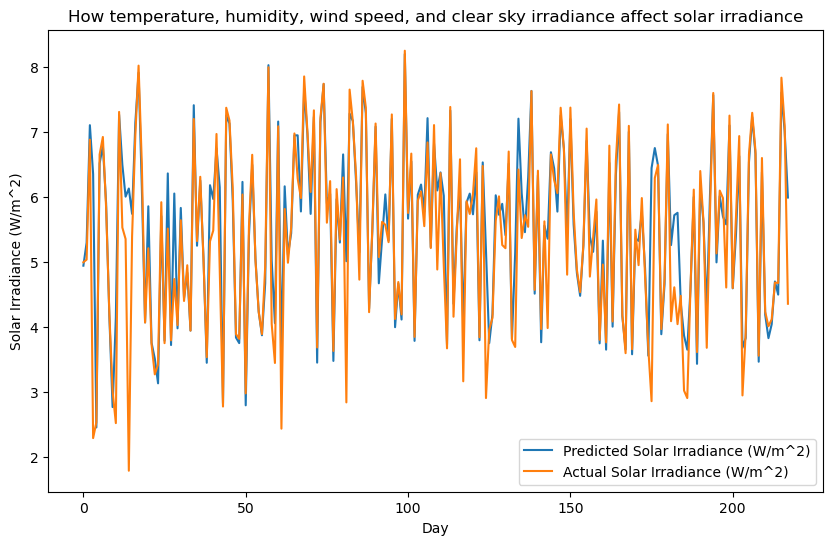

In [7]:
# plot predicted values as a line and actual values as another line
# add the x and y axis labels to show units
# add a title to the plot
plt.figure(figsize=(10, 6))
# add x and y axis labels
plt.xlabel('Day')
plt.ylabel('Solar Irradiance (W/m^2)')
plt.plot(y_pred, label='Predicted Solar Irradiance (W/m^2)')
plt.plot(y_test.values, label='Actual Solar Irradiance (W/m^2)')
plt.legend()
plt.title('How temperature, humidity, wind speed, and clear sky irradiance affect solar irradiance')
plt.show()

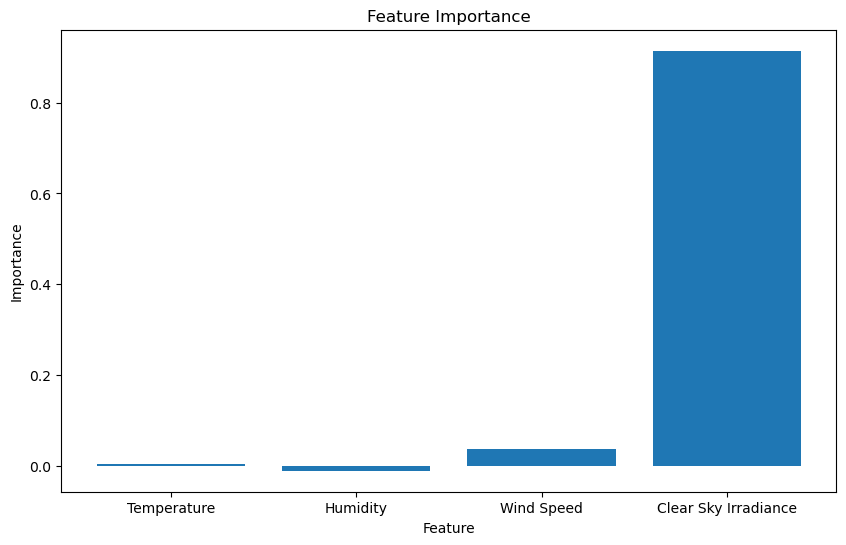

In [8]:
# Bar plot showing the importance of each feature
importance = model.coef_[0,:]
plt.figure(figsize=(10, 6))
plt.bar(X.columns, importance)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()